In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [18]:
# LOAD THE DATASET

df = pd.read_csv('/content/Mall_Customers.csv')

print("Shape:", df.shape)
df.head()


Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [19]:
# QUICK EXPLORATION

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


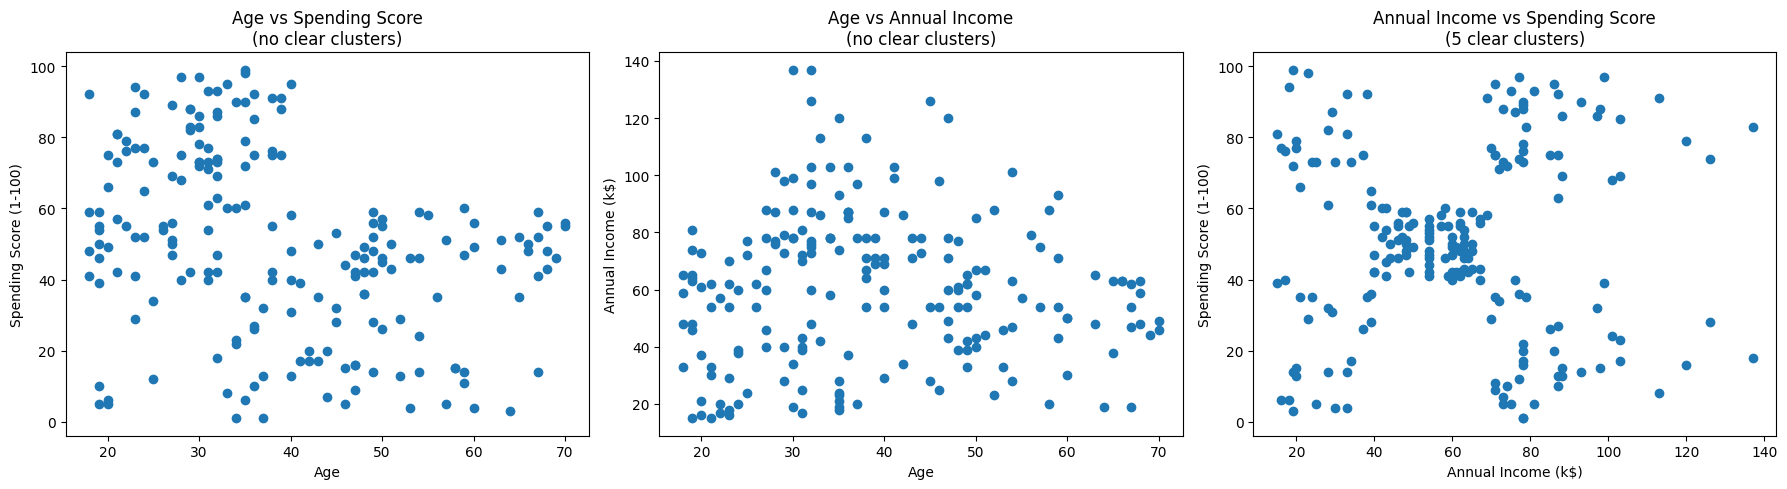

In [20]:
# FEATURE SELECTION - WHICH COLUMNS ACTUALLY SHOW CLUSTERS?
# Before picking features, visually check which pairs show natural
# groupings. Age doesn't produce clear clusters with either other
# column - Income vs Spending Score does.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['Age'], df['Spending Score (1-100)'])
axes[0].set_title("Age vs Spending Score\n(no clear clusters)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Spending Score (1-100)")

axes[1].scatter(df['Age'], df['Annual Income (k$)'])
axes[1].set_title("Age vs Annual Income\n(no clear clusters)")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Annual Income (k$)")

axes[2].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
axes[2].set_title("Annual Income vs Spending Score\n(5 clear clusters)")
axes[2].set_xlabel("Annual Income (k$)")
axes[2].set_ylabel("Spending Score (1-100)")

plt.tight_layout()
plt.show()

In [21]:
# SELECT FEATURES FOR CLUSTERING

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Check for missing values before proceeding
print("Missing values:\n", X.isnull().sum())


Missing values:
 Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [22]:
# FEATURE SCALING
# K-Means measures distance between points, so features on different
# scales (Income up to 137, Spending Score up to 100) should be scaled
# so neither feature unfairly dominates the distance calculation.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


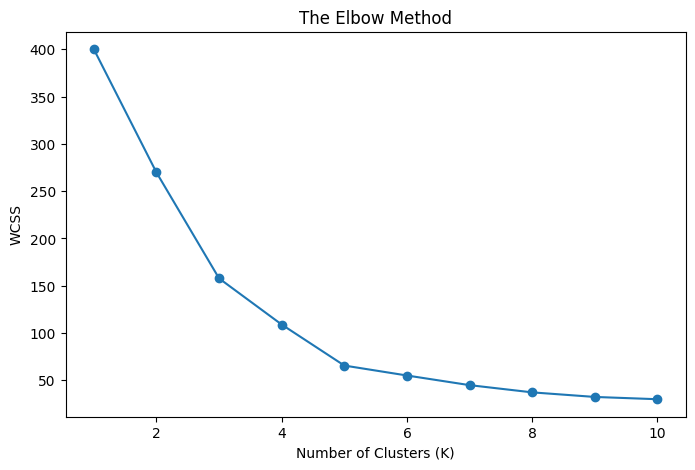

In [23]:
# ELBOW METHOD - FIND THE OPTIMAL NUMBER OF CLUSTERS (K)
# WCSS = Within-Cluster Sum of Squares - how tightly packed each
# cluster is. Look for the "elbow" point where adding more clusters
# stops giving a meaningful improvement.

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

# For this dataset, the elbow typically appears around K=5.


In [24]:
# TRAIN THE FINAL K-MEANS MODEL

K = 5  # chosen from the elbow plot above

kmeans = KMeans(n_clusters=K, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add the cluster assignment back onto the original (unscaled) data,
# so it stays human-readable for interpretation later.
df['Cluster'] = cluster_labels



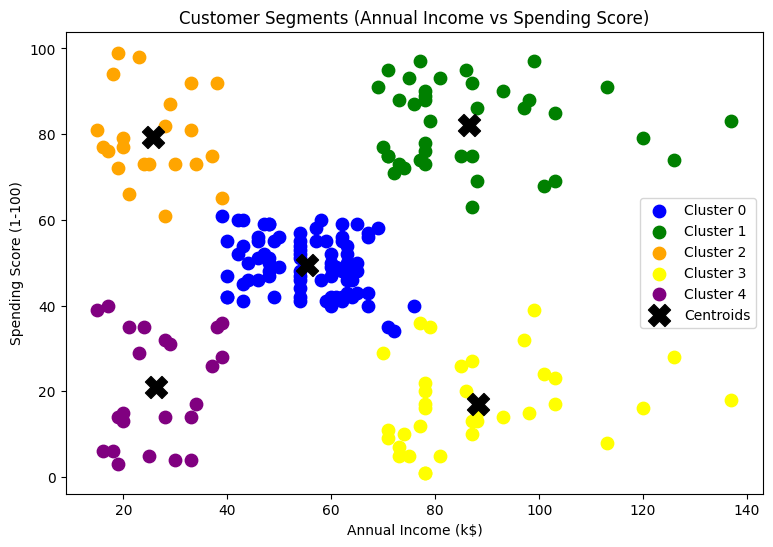

In [25]:
# VISUALIZE THE CLUSTERS
# Plotted using the ORIGINAL (unscaled) values so axes are in real
# dollars/scores, not scaled numbers.

plt.figure(figsize=(9, 6))
colors = ['blue', 'green', 'orange', 'yellow', 'purple']

for cluster_num in range(K):
    cluster_points = df[df['Cluster'] == cluster_num]
    plt.scatter(cluster_points['Annual Income (k$)'],
                cluster_points['Spending Score (1-100)'],
                s=80, c=colors[cluster_num], label=f'Cluster {cluster_num}')

# Plot centroids - inverse_transform to convert back to original scale
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            s=250, c='black', marker='X', label='Centroids')

plt.title('Customer Segments (Annual Income vs Spending Score)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()



In [26]:
# EVALUATE CLUSTER QUALITY

score = silhouette_score(X_scaled, cluster_labels)
print("Silhouette Score:", round(score, 3))
# Ranges from -1 to 1. Closer to 1 = well-separated, distinct clusters.


Silhouette Score: 0.555


In [27]:
# INTERPRET THE CLUSTERS - THE ACTUAL BUSINESS ANSWER
# Look at average Income and Spending Score per cluster to describe
# each group in plain business terms for the marketing team.

cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
cluster_summary['Customer Count'] = df['Cluster'].value_counts().sort_index()

print(cluster_summary)


          Age  Annual Income (k$)  Spending Score (1-100)  Customer Count
Cluster                                                                  
0        42.7                55.3                    49.5              81
1        32.7                86.5                    82.1              39
2        25.3                25.7                    79.4              22
3        41.1                88.2                    17.1              35
4        45.2                26.3                    20.9              23


In [28]:
# LABEL EACH CLUSTER WITH A BUSINESS-FRIENDLY NAME
# NOTE: match these labels to YOUR actual cluster_summary numbers above -
# cluster numbers can come out in a different order each run.

cluster_names = {
    0: "Standard - Medium Income, Medium Spending",
    1: "Target Customers - High Income, High Spending",
    2: "Careful Spenders - High Income, Low Spending",
    3: "Budget Conscious - Low Income, Low Spending",
    4: "Impulsive - Low Income, High Spending"
}

df['Segment'] = df['Cluster'].map(cluster_names)
df[['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)', 'Segment']].head(10)



,CustomerID,Annual Income (k$),Spending Score (1-100),Segment
0,1,15,39,"Impulsive - Low Income, High Spending"
1,2,15,81,"Careful Spenders - High Income, Low Spending"
2,3,16,6,"Impulsive - Low Income, High Spending"
3,4,16,77,"Careful Spenders - High Income, Low Spending"
4,5,17,40,"Impulsive - Low Income, High Spending"
5,6,17,76,"Careful Spenders - High Income, Low Spending"
6,7,18,6,"Impulsive - Low Income, High Spending"
7,8,18,94,"Careful Spenders - High Income, Low Spending"
8,9,19,3,"Impulsive - Low Income, High Spending"
9,10,19,72,"Careful Spenders - High Income, Low Spending"
